In [1]:
#### Cell 0: Imports and Setup

# 1. Problem Selection and Configuration
#According to Table 2 in the Parallel Variation Operator Strategy: Equal‑Budget Parallel Crossover Ensembles for NSGA‑II
problem_name = "zdt1"
n_var = 30  # Custom number of decision variables 
n_obj = 2  # Custom number of objectives

# 2. Population Settings
# -----------------------
pop_size = 100
generations = 200

# 3. Operator-specific parameters
#According to Table 1 in the Parallel Variation Operator Strategy: Equal‑Budget Parallel Crossover Ensembles for NSGA‑II
crossover_probability = 0.9
mutation_sigma = 0.5           
distribution_index_n_c = 15    # For simulated binary crossover
distribution_index_n_m = 20    # For polynomial mutation
blend_alpha = 0.5              # for blend crossover
swap_prob = 0.5                # For uniform crossover 


# 4. Select Crossover and Mutation Operators
# List all desired crossover operators to be applied in parallel.
selected_crossover_operator_names = [
    "simulated_binary_crossover_batch",
    "single_point_crossover_batch",
    "blend_crossover_batch",
    "uniform_crossover_batch"
    
]

selected_mutation_operator_name = "polynomial_mutation_batch"

In [2]:
# Cell 1:


import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
from IPython.display import display, clear_output
import time  
from pymoo.indicators.hv import HV
from pymoo.indicators.igd import IGD
import random
from pymoo.problems import get_problem
from pymoo.operators.crossover.sbx import SBX
# --- Additional Metrics Imports (if not already imported) ---
from pymoo.indicators.gd import GD
from pymoo.indicators.gd_plus import GDPlus
from pymoo.indicators.igd_plus import IGDPlus
from pymoo.indicators.spacing import SpacingIndicator as Spacing
%matplotlib inline
plt.ion()  

# benchmarks.py
from pymoo.problems import get_problem as _get_problem

def _family(name: str) -> str:
    n = name.lower()
    if n.startswith("zdt"): return "zdt"
    if n.startswith("wfg"): return "wfg"
    if n.startswith("dtlz"): return "dtlz"
    if n.startswith("c") and "dtlz" in n: return "cdtlz"  # e.g. c1dtlz1
    return "unknown"

def get_problem_dynamic(name: str, n_var: int | None = None, n_obj: int | None = None):
    """
    Robustly instantiate a Pymoo problem without you having to remember the exact signature.
    Tries the 'right' order per family, then falls back gracefully.
    """
    fam = _family(name)

    # preferred try-orders per family
    if fam in {"dtlz", "wfg"}:
        attempts = [
            lambda: _get_problem(name, n_var=n_var, n_obj=n_obj),
            lambda: _get_problem(name, n_var=n_var),
            lambda: _get_problem(name),
        ]
    elif fam == "zdt":
        attempts = [
            lambda: _get_problem(name, n_var=n_var),
            lambda: _get_problem(name),
        ]
    elif fam == "cdtlz":
        attempts = [
            lambda: _get_problem(name),  # many constrained DTLZ variants expose fixed dims
            lambda: _get_problem(name, n_var=n_var, n_obj=n_obj),
            lambda: _get_problem(name, n_var=n_var),
        ]
    else:
        attempts = [
            lambda: _get_problem(name, n_var=n_var, n_obj=n_obj),
            lambda: _get_problem(name, n_var=n_var),
            lambda: _get_problem(name),
        ]

    last_err = None
    for a in attempts:
        try:
            return a()
        except TypeError as e:    # signature mismatch
            last_err = e
        except Exception as e:    # other errors (invalid name, etc.)
            last_err = e

    raise RuntimeError(
        f"Could not instantiate '{name}' with n_var={n_var}, n_obj={n_obj}. Last error: {last_err}"
    )







=== Running NSGA-II with seed 1 ===
Survival counts by operator: {np.str_('blend_crossover_batch'): np.int64(17), np.str_('parent'): np.int64(35), np.str_('simulated_binary_crossover_batch'): np.int64(17), np.str_('single_point_crossover_batch'): np.int64(14), np.str_('uniform_crossover_batch'): np.int64(17)}

Compiled modules for significant speedup can not be used!
https://pymoo.org/installation.html#installation

To disable this warning:
from pymoo.config import Config
Config.warnings['not_compiled'] = False

Gen 1: hypervolume=0.0000, igd=1.9688, gd=2.5420, gd_plus=2.5420, igd_plus=1.9687, spacing=0.1011, generation=1.0000, generation_time=0.5593
Survival counts by operator: {np.str_('blend_crossover_batch'): np.int64(13), np.str_('parent'): np.int64(47), np.str_('simulated_binary_crossover_batch'): np.int64(14), np.str_('single_point_crossover_batch'): np.int64(17), np.str_('uniform_crossover_batch'): np.int64(9)}
Gen 2: hypervolume=0.0000, igd=1.9688, gd=2.4608, gd_plus=2.4608, 

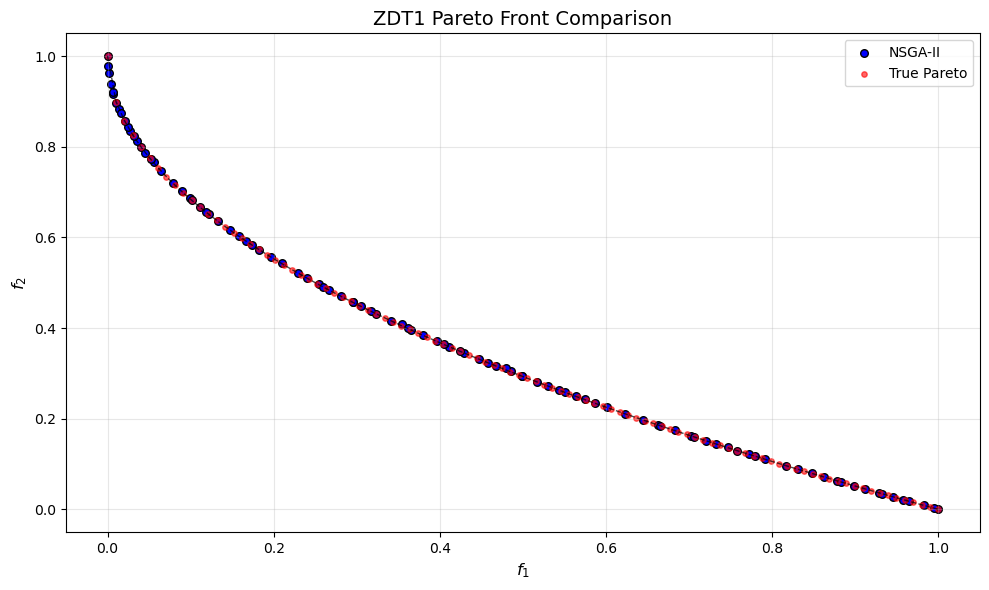

In [3]:




# Cell 2: Configuration Parameters

# =============================================================================
#                            PVOS-4C Configuration
# =============================================================================



problem = get_problem_dynamic(problem_name, n_var=n_var, n_obj=n_obj)


D = problem.n_var        
M = problem.n_obj        
min_values = problem.xl  
max_values = problem.xu  
mutation_probability = 1/D 







# --- Dictionary Mapping for Metrics ---
metrics_dict = {
    "hv": lambda front, ref_point: HV(ref_point=ref_point).do(front) if ref_point is not None else None,
    "igd": lambda front, true_front: IGD(true_front).do(front),
    "gd": lambda front, true_front: GD(true_front).do(front),
    "gd_plus": lambda front, true_front: GDPlus(true_front).do(front),
    "igd_plus": lambda front, true_front: IGDPlus(true_front).do(front),
    "spacing": lambda front: np.nan if front.shape[0] < 2 else Spacing().do(front)

}



#  Random Seed for Reproducibility
# -----------------------------------
random_seed = 1 


#  Visualization Settings
# --------------------------
plot_interval = 1
display_intermediate = False


#  Metrics Computation Control
compute_metrics_each_gen = True    # Set True to compute metrics every generation
default_metrics_interval = 1    # Interval to use if not computing each generation




# main.ipynb - Cell 3
import numpy as np


def initial_population(population_size, min_values, max_values, problem):
    # Generate random decision variables within bounds
    rand_matrix = np.random.rand(population_size, problem.n_var)
    decision_vars = min_values + rand_matrix * (max_values - min_values)
    
    if hasattr(problem, 'n_constr') and problem.n_constr > 0:
        # Evaluate and get both objectives and constraints
        eval_result = problem.evaluate(decision_vars, return_values_of=['F', 'G'])
        F = eval_result[0]
        G = eval_result[1]
        # Compute aggregated constraint violation (CV) for each individual
        CV = np.sum(np.maximum(G, 0), axis=1, keepdims=True)
        if F.ndim == 3 and F.shape[1] == 1:
            F = np.squeeze(F, axis=1)
        return np.hstack([decision_vars, F, CV])
    else:
        eval_result = problem.evaluate(decision_vars)
        if isinstance(eval_result, tuple):
            F = eval_result[0]
        else:
            F = eval_result
        if F.ndim == 3 and F.shape[1] == 1:
            F = np.squeeze(F, axis=1)
        return np.hstack([decision_vars, F])






def fast_non_dominated_sort(population, num_objectives, num_constraints=0):


    
    population_size = population.shape[0]
    if num_constraints > 0:
        # Determine the starting index of objectives (exclude decision variables and constraint column)
        D = population.shape[1] - num_objectives - num_constraints
        F = population[:, D:D+num_objectives]
        cv = population[:, -num_constraints].flatten()  # aggregated constraint violation
        feasible = (cv == 0)
        
        # Pairwise objective comparisons (for feasible solutions)
        ObjA = F[:, None, :]  # shape (n, 1, M)
        ObjB = F[None, :, :]   # shape (1, n, M)
        dom_obj = (ObjA <= ObjB).all(axis=2) & (ObjA < ObjB).any(axis=2)
        
        # For infeasible solutions, compare only based on constraint violation
        cv_i = cv[:, None]
        cv_j = cv[None, :]
        dom_cv = cv_i < cv_j
        
        # Overall dominance: a feasible solution always dominates an infeasible one.
        # If both are feasible, use objective dominance.
        # If both are infeasible, the one with lower CV is better.
        dominates = ((feasible[:, None] & ~feasible[None, :]) |
                     (feasible[:, None] & feasible[None, :] & dom_obj) |
                     ((~feasible[:, None]) & (~feasible[None, :]) & dom_cv))
    else:
        F = population[:, -num_objectives:]
        ObjA = F[:, None, :]
        ObjB = F[None, :, :]
        dominates = (ObjA <= ObjB).all(axis=2) & (ObjA < ObjB).any(axis=2)
    

    adjacency = dominates
    n_dominate = adjacency.sum(axis=0)

    # Initialize rank assignments
    rank = np.full(population_size, -1, dtype=int)
    current_front = np.where(n_dominate == 0)[0]
    rank_level = 1

    # Identify subsequent Pareto fronts
    while len(current_front) > 0:
        rank[current_front] = rank_level
        dominated_any = adjacency[current_front, :].any(axis=0)
        
        counts = adjacency[current_front, :][:, dominated_any].sum(axis=0)
        n_dominate[dominated_any] -= counts

        newly_zero = (n_dominate == 0) & (rank == -1)
        current_front = np.where(newly_zero)[0]
        rank_level += 1

    return rank


def crowding_distance(population, num_objectives, front_indices):
    """
    Compute the crowding distance for the sub-population specified by 'front_indices'.
    """
    # Initialize crowding distance array for entire population
    cd = np.zeros(population.shape[0])
    
    # Handle boundary conditions: empty front or very small front
    if len(front_indices) == 0:
        return cd
    if len(front_indices) <= 2:
        cd[front_indices] = np.inf
        return cd

    # Extract objectives for the current front
    objectives = population[front_indices, problem.n_var: problem.n_var + num_objectives]

    num_individuals = len(front_indices)
    cd_local = np.zeros(num_individuals)

    # Calculate crowding distance for each objective
    for m in range(num_objectives):
        # Sort indices based on objective m
        sorted_idx_local = np.argsort(objectives[:, m])
        sorted_vals = objectives[sorted_idx_local, m]

        # Assign infinity to boundary points
        cd_local[sorted_idx_local[0]] = np.inf
        cd_local[sorted_idx_local[-1]] = np.inf

        # Normalize distance between neighboring individuals
        denom = sorted_vals[-1] - sorted_vals[0]
        if denom == 0:
            continue

        for i in range(1, num_individuals - 1):
            cd_local[sorted_idx_local[i]] += (sorted_vals[i+1] - sorted_vals[i-1]) / denom

    # Update the crowding distance for individuals in the current front
    cd[front_indices] = cd_local
    return cd


def compare_individuals(rank1, rank2, cd1, cd2):
    """
    Compare two individuals based on Pareto rank and crowding distance.
    """
    # Return True if first individual is better than second based on rank, 
    # or same rank but higher crowding distance.
    return (rank1 < rank2) | ((rank1 == rank2) & (cd1 > cd2))


def select_parents_batch(population, rank, cd, population_size):
    """
    Perform binary tournament selection in a vectorized manner to select parents.
    """
    total_individuals = population.shape[0]
    
    # First set of parents selection
    idx = np.random.randint(0, total_individuals, size=(population_size, 2))
    better = compare_individuals(rank[idx[:, 0]], rank[idx[:, 1]], cd[idx[:, 0]], cd[idx[:, 1]])
    parent1_idx = idx[:, 0]
    parent2_idx = idx[:, 1]
    selected_parents1 = np.where(better, parent1_idx, parent2_idx)

    # Second set of parents selection
    idx = np.random.randint(0, total_individuals, size=(population_size, 2))
    better = compare_individuals(rank[idx[:, 0]], rank[idx[:, 1]], cd[idx[:, 0]], cd[idx[:, 1]])
    parent1_idx = idx[:, 0]
    parent2_idx = idx[:, 1]
    selected_parents2 = np.where(better, parent1_idx, parent2_idx)

    return selected_parents1, selected_parents2

#cell 4

def simulated_binary_crossover_batch(parents_dec_1, parents_dec_2,
                                     crossover_probability, distribution_index_n_c,
                                     min_values, max_values, eps=1e-14):
    """
    Perform Simulated Binary Crossover (SBX) on a batch of parent pairs.

    This implementation mimics the pymoo SBX operator with gene‐wise crossover probabilities,
    handling cases when parent genes are too close or when lower and upper bounds are identical.
    
    Parameters:
        parents_dec_1 (np.ndarray): Decision variables of parent 1, shape (N, D).
        parents_dec_2 (np.ndarray): Decision variables of parent 2, shape (N, D).
        crossover_probability (float): Probability of performing crossover per gene.
        distribution_index_n_c (float): Crossover distribution index (η₍c₎).
        min_values (np.ndarray): Lower bounds for decision variables, shape (D,).
        max_values (np.ndarray): Upper bounds for decision variables, shape (D,).
        eps (float): A small constant to avoid numerical issues when parent genes are nearly equal.
        
    Returns:
        
    """
    N, D = parents_dec_1.shape
    eta_c = distribution_index_n_c

    # Initialize offspring as copies of the parents.
    
    c1_new = parents_dec_1.copy()

    # Create a gene-wise mask deciding whether to perform crossover.
    do_cross = np.random.rand(N, D) < crossover_probability

    # Disable crossover for genes where the parents are too close.
    do_cross[np.abs(parents_dec_1 - parents_dec_2) <= eps] = False

    # Disable crossover for genes where the lower and upper bounds are identical.
    do_cross[:, (min_values == max_values)] = False

    # Compute gene-wise minima and maxima.
    y1 = np.minimum(parents_dec_1, parents_dec_2)
    y2 = np.maximum(parents_dec_1, parents_dec_2)
    delta = y2 - y1

    # Prepare arrays to hold the new offspring values.



    if np.any(do_cross):
        # === First Child Calculation ===
        # Compute beta for the first offspring using the lower bound.
        beta1 = 1.0 + 2.0 * (y1 - min_values) / (delta + eps)
        # Calculate alpha1 as in pymoo: 2 - beta^(-(η₍c₎+1))
        alpha1 = 2.0 - np.power(beta1, -(eta_c + 1.0))
        # Draw independent random numbers for each gene.
        rand1 = np.random.rand(N, D)
        # Compute betaq1 according to the condition.
        betaq1 = np.where(rand1 <= (1.0 / alpha1),
                          np.power(rand1 * alpha1, 1.0 / (eta_c + 1.0)),
                          np.power(1.0 / (2.0 - rand1 * alpha1), 1.0 / (eta_c + 1.0)))
        # Compute the offspring gene values.
        c1_calc = 0.5 * ((y1 + y2) - betaq1 * delta)






        # Assign the newly calculated gene values only where crossover is applied.
        c1_new[do_cross] = c1_calc[do_cross]


    # Clip the offspring to ensure they lie within the given bounds.
    
    

    return np.clip(c1_new, min_values, max_values)



def single_point_crossover_batch(parents_dec_1, parents_dec_2, crossover_probability, min_values, max_values):
    """
    Perform single-point crossover on a batch of parent pairs.

    Parameters:
        parents_dec_1 (np.ndarray): Decision variables of parent 1, shape (N, D).
        parents_dec_2 (np.ndarray): Decision variables of parent 2, shape (N, D).
        crossover_probability (float): Probability of performing crossover on a parent pair.
        min_values (np.ndarray): Lower bounds for decision variables, shape (D,).
        max_values (np.ndarray): Upper bounds for decision variables, shape (D,).

    Returns:
        
    """
    num_offspring, num_decision_variables = parents_dec_1.shape
    # Initialize offspring arrays as copies of parent genes
    child1 = parents_dec_1.copy()
    

    # Create a mask to decide which pairs will undergo crossover
    crossover_mask = np.random.rand(num_offspring) < crossover_probability

    # Get indices of parent pairs that will crossover
    crossover_indices = np.nonzero(crossover_mask)[0]

    # For each selected pair, determine a random crossover point and perform crossover
    if crossover_indices.size > 0:
        # Randomly select a crossover point for each individual selected for crossover
        crossover_points = np.random.randint(1, num_decision_variables, size=crossover_indices.size)

        # Iterate over each selected pair and apply single-point crossover
        for idx, cp in zip(crossover_indices, crossover_points):
            # Swap segments after the crossover point between the two parents
            child1[idx, cp:] = parents_dec_2[idx, cp:]

    # Ensure offspring values are within the specified bounds
    child1 = np.clip(child1, min_values, max_values)
    

    return np.clip(child1, min_values, max_values)





import numpy as np

def blend_crossover_batch(parents_dec_1, parents_dec_2, crossover_probability, alpha_blend, min_values, max_values):
    """
    Perform BLX-α (Blend Crossover) on a batch of parent pairs.

    Parameters:
        parents_dec_1 (np.ndarray): Decision variables of parent 1, shape (N, D).
        parents_dec_2 (np.ndarray): Decision variables of parent 2, shape (N, D).
        crossover_probability (float): Probability of crossover.
        alpha_blend (float): Blend factor α controlling the range extension.
        min_values (np.ndarray): Lower bounds for decision variables, shape (D,).
        max_values (np.ndarray): Upper bounds for decision variables, shape (D,).

    Returns:
        tuple: Two arrays containing offspring decision variables, each of shape (N, D).
    """
    # Determine the number of parent pairs (N) and number of decision variables (D).
    N, D = parents_dec_1.shape

    # Initialize offspring arrays as copies of the parent decision variables.
    child1 = parents_dec_1.copy()
    

    # Determine which parent pairs will undergo crossover based on probability.
    do_cross = np.random.rand(N) < crossover_probability

    # If no pairs are selected, return the copies.
    if not np.any(do_cross):
        return child1

    # Extract only the parent pairs selected for crossover.
    p1 = parents_dec_1[do_cross, :]
    p2 = parents_dec_2[do_cross, :]

    # Compute element-wise minima and maxima for each gene.
    y1 = np.minimum(p1, p2)
    y2 = np.maximum(p1, p2)
    d = y2 - y1  # difference between the parents for each gene

    # Calculate the extended lower and upper bounds for each gene.
    lower_bound = y1 - alpha_blend * d
    upper_bound = y2 + alpha_blend * d

    # Generate two sets of random numbers for each gene of each selected pair.
    rand1 = np.random.rand(p1.shape[0], D)
    

    # Create offspring within the extended range.
    c1 = lower_bound + rand1 * (upper_bound - lower_bound)
    

    # Assign the newly generated offspring back into the full child arrays.
    child1[do_cross, :] = c1
    

    # Ensure offspring values stay within the specified bounds.
    child1 = np.clip(child1, min_values, max_values)
    

    return child1


import numpy as np

def uniform_crossover_batch(parents_dec_1, parents_dec_2, crossover_probability,  min_values, max_values, swap_prob=swap_prob):
    """
    Perform Uniform Crossover on a batch of parent pairs.

    Parameters:
        parents_dec_1 (np.ndarray): Decision variables of parent 1, shape (N, D).
        parents_dec_2 (np.ndarray): Decision variables of parent 2, shape (N, D).
        crossover_probability (float): Probability of performing crossover on each parent pair.
        swap_prob (float, optional): Probability of swapping each gene. Defaults to 0.5.
        min_values (np.ndarray): Lower bounds for decision variables, shape (D,).
        max_values (np.ndarray): Upper bounds for decision variables, shape (D,).

    Returns:
        tuple: Two arrays containing offspring decision variables, each of shape (N, D).
    """
    # Determine the number of parent pairs (N) and number of decision variables (D).
    N, D = parents_dec_1.shape
    p_c = crossover_probability

    # Initialize offspring arrays as copies of the parent decision variables.
    child1 = parents_dec_1.copy()
    

    # Determine which parent pairs will undergo crossover based on probability.
    do_cross = np.random.rand(N) < p_c

    # If no pairs are selected for crossover, return the copies.
    if not np.any(do_cross):
        return child1

    # Extract the parent pairs selected for crossover.
    p1 = parents_dec_1[do_cross, :]
    p2 = parents_dec_2[do_cross, :]

    # Generate a mask for each gene indicating whether to swap based on swap_prob.
    swap_mask = np.random.rand(p1.shape[0], D) < swap_prob

    # Create copies to hold the offspring genes.
    offspring1 = p1.copy()
    

    # Perform the swap where the mask is True.
    offspring1[swap_mask] = p2[swap_mask]
    

    # Assign the offspring genes back to the full child arrays.
    child1[do_cross, :] = offspring1
    

    # Ensure offspring values are within the specified bounds.
    child1 = np.clip(child1, min_values, max_values)
   

    # Return the generated offspring decision variables.
    return child1





def polynomial_mutation_batch(offspring_dec, mutation_probability, distribution_index_n_m,
                              min_values, max_values, at_least_once=False):
    """
    Perform Polynomial Mutation on a batch of offspring decision variables.

    This operator follows the conventional scheme (as in pymoo) and
    applies a mutation to each gene with a given probability.
    
    Parameters:
        offspring_dec (np.ndarray): Offspring decision variables, shape (N, D).
        mutation_probability (float): Mutation probability per gene.
        distribution_index_n_m (float): Mutation distribution index (η₍m₎).
        min_values (np.ndarray): Lower bounds for decision variables, shape (D,).
        max_values (np.ndarray): Upper bounds for decision variables, shape (D,).
        at_least_once (bool): If True, ensure that at least one gene per individual is mutated.
        
    Returns:
        np.ndarray: Mutated offspring decision variables, shape (N, D).
    """
    N, D = offspring_dec.shape
    p_m = mutation_probability
    eta_m = distribution_index_n_m

    # Create a gene-wise mutation mask.
    mutation_mask = np.random.rand(N, D) < p_m
    # Do not allow mutation where lower and upper bounds are identical.
    mutation_mask[:, (min_values == max_values)] = False

    # If at_least_once is True, force at least one mutation per individual (if possible).
    if at_least_once:
        for i in range(N):
            if not np.any(mutation_mask[i]):
                # Identify genes that are allowed to be mutated.
                allowed = np.where(min_values != max_values)[0]
                if allowed.size > 0:
                    j = np.random.choice(allowed)
                    mutation_mask[i, j] = True

    # Convert offspring_dec to float for mutation computations.
    x = offspring_dec.astype(float).copy()

    # Compute the range for each decision variable.
    range_ = max_values - min_values

    # Compute normalized distances to the bounds.
    delta1 = (x - min_values) / (range_ + 1e-14)
    delta2 = (max_values - x) / (range_ + 1e-14)

    # Generate random numbers for the mutation process.
    u = np.random.rand(N, D)

    # Initialize delta_q (the mutation step sizes).
    deltaq = np.zeros((N, D))

    # Mutation: apply the polynomial mutation formula only for genes marked for mutation.
    # Branch where u < 0.5:
    mask1 = mutation_mask & (u < 0.5)
    if np.any(mask1):
        tmp = 2 * u[mask1] + (1 - 2 * u[mask1]) * np.power(1 - delta1[mask1], (eta_m + 1))
        deltaq[mask1] = np.power(tmp, 1.0 / (eta_m + 1)) - 1.0

    # Branch where u >= 0.5:
    mask2 = mutation_mask & (u >= 0.5)
    if np.any(mask2):
        tmp = 2 * (1 - u[mask2]) + 2 * (u[mask2] - 0.5) * np.power(1 - delta2[mask2], (eta_m + 1))
        deltaq[mask2] = 1.0 - np.power(tmp, 1.0 / (eta_m + 1))

    # Apply the mutation step.
    x = x + deltaq * range_
    # Ensure the mutated values are within the bounds.
    x = np.clip(x, min_values, max_values)

    return x


def gaussian_mutation_batch(offspring_dec, mutation_probability, sigma, min_values, max_values):
    """
    Perform Gaussian mutation on a batch of offspring decision variables.
    """
    # Determine population size and number of decision variables
    num_offspring, num_decision_variables = offspring_dec.shape
    
    # Create a mutation mask for each decision variable of each offspring
    mutation_mask = np.random.rand(num_offspring, num_decision_variables) < mutation_probability
    # Generate Gaussian noise where mutation is to be applied
    noise = np.random.normal(0, sigma, (num_offspring, num_decision_variables)) * mutation_mask
    # Apply mutation
    offspring_dec = offspring_dec + noise
    
    # Ensure mutated offspring values are within bounds
    offspring_dec = np.clip(offspring_dec, min_values, max_values)
    return offspring_dec



# Cell 5: Complete PVOS-4C Implementation with Pymoo Benchmarks
from joblib import Parallel, delayed
from pymoo.core.population import Population
from pymoo.core.individual import Individual

class _ArrayProblem:
    """Minimal stub so SBX sees n_var, xl, xu."""
    def __init__(self, xl, xu):
        self.xl, self.xu = xl, xu
        self.n_var = len(xl)
def run_nsga2(problem, population_size, generations,
             crossover_probability, mutation_probability,
             selected_crossover_operator_names,
             selected_mutation_operator_name,
             distribution_index_n_c, distribution_index_n_m,
             blend_alpha, swap_prob, mutation_sigma,
             random_seed, plot_interval, display_intermediate,
             metrics_interval):
    
    # Get problem parameters from Pymoo object
    num_objectives = problem.n_obj
    num_decision_variables = problem.n_var
    min_values = problem.xl
    max_values = problem.xu
    num_constraints = 1 if (hasattr(problem, 'n_constr') and problem.n_constr > 0) else 0

    # Initialize operator map
    operator_map = {
        "simulated_binary_crossover_batch": simulated_binary_crossover_batch,
        "single_point_crossover_batch": single_point_crossover_batch,
        "polynomial_mutation_batch": polynomial_mutation_batch,
        "gaussian_mutation_batch": gaussian_mutation_batch,
        "blend_crossover_batch": blend_crossover_batch,
        "uniform_crossover_batch": uniform_crossover_batch
    }

    # Convert crossover operator names to function objects
    crossover_ops = [operator_map[co_name] for co_name in selected_crossover_operator_names]
    # Get mutation operator
    selected_mutation_operator = operator_map[selected_mutation_operator_name]

    # Set random seeds
    np.random.seed(random_seed)
    random.seed(random_seed)

    # Initialize population
    population = initial_population(population_size, min_values, max_values, problem)
    metrics_history = []

    # Helper function for parallel variation
    def apply_crossover_and_mutation(co, parents_dec_1, parents_dec_2, selected_mutation_operator,
                                     mutation_probability, distribution_index_n_c, distribution_index_n_m,
                                     mutation_sigma, blend_alpha, swap_prob, min_values, max_values, 
                                     crossover_probability):
        # Apply the specified crossover operator, each crossover produced one child.
        if co == simulated_binary_crossover_batch:
            sbx = SBX(prob=crossover_probability,
                      eta=distribution_index_n_c,
                      n_offsprings=1)
        
            _prob = _ArrayProblem(min_values, max_values)
        
            matings = [[Individual(X=p1), Individual(X=p2)]
                       for p1, p2 in zip(parents_dec_1, parents_dec_2)]
        
            # single call → (N, D) offspring
            child_dec = sbx.do(_prob, matings).get("X")      
               


        elif co == single_point_crossover_batch:
            
            child_dec= single_point_crossover_batch(
                parents_dec_1,
                parents_dec_2,
                crossover_probability,
                min_values,
                max_values
            )
        elif co == blend_crossover_batch:
            child_dec = blend_crossover_batch(
                parents_dec_1,
                parents_dec_2,
                crossover_probability,
                blend_alpha,
                min_values,
                max_values
            )
        elif co == uniform_crossover_batch:
            child_dec = uniform_crossover_batch(
                parents_dec_1,
                parents_dec_2,
                crossover_probability,
                min_values,
                max_values,
                swap_prob
            )
  

        else:
            raise ValueError("Crossover operator not recognized.")
    
        # Apply the selected mutation operator on the offspring
        if selected_mutation_operator == polynomial_mutation_batch:
            child_dec = polynomial_mutation_batch(
                child_dec,
                mutation_probability,
                distribution_index_n_m,
                min_values,
                max_values
            )

        elif selected_mutation_operator == gaussian_mutation_batch:
            child_dec = gaussian_mutation_batch(
                child_dec,
                mutation_probability,
                mutation_sigma,
                min_values,
                max_values
            )

        else:
            raise ValueError("Selected mutation operator not recognized.")
    
        # Evaluate offspring
        offspring_dec = child_dec                         
        
        if hasattr(problem, 'n_constr') and problem.n_constr > 0:
            F, G = problem.evaluate(offspring_dec, return_values_of=['F', 'G'])
            CV   = np.sum(np.maximum(G, 0), axis=1, keepdims=True)
            if F.ndim == 3 and F.shape[1] == 1:
                F = np.squeeze(F, axis=1)
            offspring = np.hstack([offspring_dec, F, CV])
        else:
            eval_result = problem.evaluate(offspring_dec)
            F = eval_result[0] if isinstance(eval_result, tuple) else eval_result
            if F.ndim == 3 and F.shape[1] == 1:
                F = np.squeeze(F, axis=1)
            offspring = np.hstack([offspring_dec, F])
        
        return {"offspring": offspring, "operator": co.__name__}



    # Main evolutionary loop
    for generation in range(1, generations + 1):
        gen_start = time.time()
        
        # Non-dominated sorting
        rank = fast_non_dominated_sort(population, num_objectives, num_constraints)

        
        # Crowding distance calculation
        crowding = np.zeros(len(population))
        for r in range(1, rank.max()+1):
            front_idx = np.where(rank == r)[0]
            crowding += crowding_distance(population, num_objectives, front_idx)


        pair_cnt = population_size // len(crossover_ops)      #pop_size (N)/ number of crossovers (K): for example: 25 pairs when pop_size = 100
        p1_idx, p2_idx = select_parents_batch(population, rank, crowding, pair_cnt)
        parents1 = population[p1_idx, :num_decision_variables]
        parents2 = population[p2_idx, :num_decision_variables]

     
        results = Parallel(n_jobs=len(crossover_ops))(  # the 4 crossovers work in parallel 
            delayed(apply_crossover_and_mutation)(
                op, parents1, parents2,
                selected_mutation_operator,
                mutation_probability,
                distribution_index_n_c,
                distribution_index_n_m,
                mutation_sigma,
                blend_alpha,
                swap_prob,
                min_values,
                max_values,
                crossover_probability
            ) for op in crossover_ops
        )

        
        # Separate offspring and operator labels into lists
        offspring_list = []
        operator_ids_list = []
        for res in results:
            offspring_list.append(res["offspring"])
            # Create an array filled with the operator name for each offspring row
            operator_ids_list.append(np.full(res["offspring"].shape[0], res["operator"]))
        
        # Combine offspring from all operators
        all_offspring = np.vstack(offspring_list)
        #all_operator_ids = np.concatenate(operator_ids_list)


        
        # Population combination and survival selection
        # Tag the original population with a default label (e.g., "parent")
        original_operator_ids = np.array(["parent"] * population.shape[0])
        
        # Combine the offspring from all operators
        combined_offspring = np.vstack(offspring_list)
        combined_operator_ids = np.concatenate([original_operator_ids, np.concatenate(operator_ids_list)])
        
        # Now combine the populations
        combined_pop = np.vstack([population, combined_offspring])
        rank_combined = fast_non_dominated_sort(combined_pop, num_objectives, num_constraints)

        crowding_combined = np.zeros(len(combined_pop))

        for r in range(1, rank_combined.max()+1):
            front_idx = np.where(rank_combined == r)[0]
            crowding_combined += crowding_distance(combined_pop, num_objectives, front_idx)

        # Environmental selection
        survivors = []
        current_rank = 1
        while len(survivors) < population_size and current_rank <= rank_combined.max():
            front_idx = np.where(rank_combined == current_rank)[0]
            if len(survivors) + len(front_idx) <= population_size:
                survivors.extend(front_idx)
            else:
                sorted_front = sorted([(i, crowding_combined[i]) for i in front_idx], 
                                    key=lambda x: -x[1])
                survivors.extend([i for i, _ in sorted_front[:population_size-len(survivors)]])
            current_rank += 1

        population = combined_pop[survivors]
        # Extract operator labels for the survivors
        surviving_operator_ids = combined_operator_ids[survivors]
        
        # Compute counts of survivors per operator
        unique, counts = np.unique(surviving_operator_ids, return_counts=True)
        survival_stats = dict(zip(unique, counts))
        print("Survival counts by operator:", survival_stats)

        # Identify the non-dominated front in the new population
        non_dominated_indices = [i for i in survivors if rank_combined[i] == 1]
        non_dominated_front = combined_pop[non_dominated_indices, problem.n_var: problem.n_var + num_objectives]

        gen_time = time.time() - gen_start

        # Metrics calculation
        if metrics_interval and generation % metrics_interval == 0:
            current_front = non_dominated_front
            
            # Reference point handling
            
            if num_objectives in [2, 3]:
                true_pareto_front = problem.pareto_front() if hasattr(problem, "pareto_front") else None
                if true_pareto_front is not None:
                    nadir_point = np.max(true_pareto_front, axis=0)
                    ref_point = nadir_point * 1.1
                else:
                    ref_point = None  # or define a default reference point, e.g., np.array([1.0, 1.0])


            else:
                ref_point = None

                
            # Metric calculations
            # Compute metrics using the mapping defined in Cell 2
            # Dictionary to hold computed metrics for this generation
            metrics_results = {}
            
            for metric_name, metric_func in metrics_dict.items():
                if metric_name == "hv":
                    metrics_results["hypervolume"] = metric_func(current_front, ref_point)
                elif metric_name in ["igd", "gd", "gd_plus", "igd_plus"]:
                    metrics_results[metric_name] = metric_func(current_front, true_pareto_front) if true_pareto_front is not None else None
                elif metric_name == "spacing":
                    metrics_results["spacing"] = metric_func(current_front)
                else:
                    # If you add other metrics with different signatures, adjust here.
                    metrics_results[metric_name] = metric_func(current_front)
            
            # Add generation and generation time to the metrics record
            metrics_results["crossover_survival"] = survival_stats
            metrics_results["generation"] = generation
            metrics_results["generation_time"] = gen_time
            
            # Append to the overall metrics history
            metrics_history.append(metrics_results)
            
            # Optionally print computed metrics for this generation
            print("Gen {}: {}".format(
                generation,
                ", ".join([f"{k}={v:.4f}" for k, v in metrics_results.items() if isinstance(v, (int, float))])
            ))
        # Visualization
        if display_intermediate and (generation % plot_interval == 0):
            current_front = non_dominated_front
            true_pf = problem.pareto_front() if hasattr(problem, 'pareto_front') else None
            
            plt.figure(figsize=(8, 6))
            if num_objectives == 2:
                plt.scatter(current_front[:, 0], current_front[:, 1], c='blue', label='Approximated')
                if true_pf is not None:
                    plt.scatter(true_pf[:, 0], true_pf[:, 1], c='red', alpha=0.5, label='True')
                plt.xlabel("f1"), plt.ylabel("f2")
            elif num_objectives == 3:
                ax = plt.axes(projection='3d')
                ax.scatter3D(current_front[:, 0], current_front[:, 1], current_front[:, 2], c='blue')
                if true_pf is not None:
                    ax.scatter3D(true_pf[:, 0], true_pf[:, 1], true_pf[:, 2], c='red', alpha=0.5)
                ax.set_xlabel("f1"), ax.set_ylabel("f2"), ax.set_zlabel("f3")
            
            plt.title(f"{problem.__class__.__name__} Generation {generation}")
            plt.legend()
            plt.show()
            clear_output(wait=True)

    return population, problem.pareto_front(), metrics_history



#cell6
def plot_pareto_front(approximated_front, true_front, problem):
    """
    Plot comparison between approximated and true Pareto fronts (using Pymoo data for the analytical solution)
    
    """
    plt.figure(figsize=(10, 6))
    
    # Get problem metadata from Pymoo
    num_objectives = problem.n_obj
    problem_name = problem.__class__.__name__
    
    if num_objectives == 2:
        # 2D Plot for approximated front
        plt.scatter(approximated_front[:, 0], approximated_front[:, 1], 
                   c='blue', s=30, edgecolors='k', label='NSGA-II')
        
        # Plot true Pareto front only if available
        if true_front is not None:
            plt.scatter(true_front[:, 0], true_front[:, 1],
                        c='red', s=15, alpha=0.6, label='True Pareto')
        
        plt.xlabel("$f_1$", fontsize=12)
        plt.ylabel("$f_2$", fontsize=12)
        plt.title(f"{problem_name} Pareto Front Comparison", fontsize=14)
        
    elif num_objectives == 3:
        # 3D Plot for approximated front
        ax = plt.axes(projection='3d')
        ax.scatter3D(approximated_front[:, 0], approximated_front[:, 1], approximated_front[:, 2],
                     c='blue', s=30, edgecolors='k', label='NSGA-II')
        if true_front is not None:
            ax.scatter3D(true_front[:, 0], true_front[:, 1], true_front[:, 2],
                         c='red', s=15, alpha=0.6, label='True Pareto')
        
        ax.set_xlabel("$f_1$", fontsize=10)
        ax.set_ylabel("$f_2$", fontsize=10)
        ax.set_zlabel("$f_3$", fontsize=10)
        ax.view_init(elev=45, azim=45)
        plt.title(f"{problem_name} 3D Pareto Front", fontsize=14)
    else:
        print(f"Visualization not supported for {num_objectives} objectives")
        return

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    # Optionally, if a true Pareto front is available and it is 2D, you can plot a continuous line.
    if true_front is not None and num_objectives == 2:
        plt.plot(true_front[:, 0], true_front[:, 1], 
                 c='black', lw=1, ls='--', alpha=0.7, label='Analytical Solution')
            
    plt.show()




# cell 7

import numpy as np
import importlib



# Determine the metrics interval based on the control flag.
metrics_interval_value = default_metrics_interval if compute_metrics_each_gen else None


# =============================================================================
#                         Modified Execution Function
# =============================================================================

def run_nsga2_for_seed(seed):
    """Run NSGA-II for a single seed with proper Pymoo integration"""
    print(f"\n=== Running NSGA-II with seed {seed} ===")
    
    
    
    problem = get_problem_dynamic(problem_name, n_var=n_var, n_obj=n_obj)
    

    


    
    # 2. Run NSGA-II with corrected parameters
    final_population, true_pareto, metrics_history = run_nsga2(
        problem=problem,  
        population_size=pop_size,
        generations=generations,
        crossover_probability=crossover_probability,
        mutation_probability=mutation_probability,
        selected_crossover_operator_names=selected_crossover_operator_names,
        selected_mutation_operator_name=selected_mutation_operator_name,
        distribution_index_n_c=distribution_index_n_c,
        distribution_index_n_m=distribution_index_n_m,
        blend_alpha=blend_alpha,
        swap_prob=swap_prob,
        mutation_sigma=mutation_sigma,
        random_seed=seed,
        plot_interval=plot_interval,
        display_intermediate=display_intermediate,
        metrics_interval=metrics_interval_value
    )
    
    # 3. Add seed information to metrics
    for metric in metrics_history:
        metric['seed'] = seed

    # 4. Identify non-dominated solutions
    num_constraints = 1 if (hasattr(problem, 'n_constr') and problem.n_constr > 0) else 0
    final_rank = fast_non_dominated_sort(final_population, problem.n_obj, num_constraints)

    non_dominated_indices = np.where(final_rank == 1)[0]
    pareto_points = final_population[non_dominated_indices, D : D + M]
    
    # 5. Plot results if enabled
    if display_intermediate:
        plot_pareto_front(pareto_points, true_pareto, problem)
        
    return {
        'seed': seed,
        'final_population': final_population,
        'true_pareto': true_pareto,
        'metrics_history': metrics_history,
        'pareto_points': pareto_points
    }

# Run NSGA-II in parallel for seeds 1 to 30 (or 31 if you prefer 1 to 31) in series 
seeds = range(1, 31)
results = Parallel(n_jobs=1)(delayed(run_nsga2_for_seed)(seed) for seed in seeds)

# Prepare containers for combined metrics and final populations.
all_metrics = []      
final_populations = []  
true_paretos = []       

# Process the results from parallel runs.
for result in results:
    seed = result['seed']
    final_populations.append(result['final_population'])
    true_paretos.append(result['true_pareto'])
    all_metrics.extend(result['metrics_history'])
    
    pareto_points = result['pareto_points']
    print(f"Seed {seed} - Number of Pareto front points: {pareto_points.shape[0]}")
    


    if pareto_points.size > 0:
        plot_pareto_front(
            approximated_front=pareto_points,
            true_front=result['true_pareto'],

            problem = get_problem_dynamic(problem_name, n_var=n_var, n_obj=n_obj)

        )
    else:
        print(f"Seed {seed}: Empty Pareto front")







    

    


In [ ]:
### Cell 8: Save Combined Metrics History to Excel 
import pandas as pd
import re

# Convert the all_metrics list to DataFrame
df_metrics = pd.DataFrame(all_metrics)

# Sanitize problem name for filename
problem_name_clean = re.sub(r'[^a-zA-Z0-9_]', '', problem.__class__.__name__).lower()


# Define a mapping from the full crossover operator names to shortcuts
crossover_shortcuts = {
    "simulated_binary_crossover_batch": "sbx",
    "blend_crossover_batch": "blx",
    "single_point_crossover_batch": "spx",
    "uniform_crossover_batch": "ux"
}

# Convert selected crossover operator names to their shortcut representation
selected_crossover_shortcut_names = [
    crossover_shortcuts.get(name, name) for name in selected_crossover_operator_names
]

# Join the shortcuts into a single string (e.g., "sbx-blx")
crossover_str = "-".join(selected_crossover_shortcut_names)

# Create valid filename
excel_filename = (
    f"{problem_name_clean} {len(selected_crossover_operator_names)} {crossover_str} cross poly "
    f"{pop_size}pop {generations}gen experiment3 PVOS-4C.xlsx"
)

#{crossover_str}

# Save to Excel
df_metrics.to_excel(excel_filename, index=False)
print(f"Metrics saved to '{excel_filename}'")